이미지넷은 1,000가지 종류로 나뉜 120만 개가 넘는 이미지를 놓고 어떤 물체인지 맞히는 '이미지넷 이미지 인식 대회(ILSVRC)'에 사용되는 데이터셋이다.

전이 학습은 '기존의 학습 결과를 가져와서 유사한 프로젝트에 사용하는 방법'을 의미한다.  
전이 학습을 적용하는 방법은 먼저 대규모 데이터셋에 학습된 기존 네트워크를 불러온다. CNN 모델의 앞쪽을 이 네트워크로 채운다. 그리고 레이어에서 내 프로젝트와 연결한다. 그리고 이 두 네트워크가 잘 맞물리게끔 미세 조정(fine tunning)을 하면 된다.

다음 모델 이름을 transfer_model로 정하고 VGG16을 불러온 모습이다.  


```
transfer_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
transfer_model.trainable = False
trainsfer_model.summary
```

include_top은 분류를 담당하는 곳을 불러올지 말지를 정하는 옵션이다. 여기서는 만든 로컬 네트워크를 연결할 것이므로 False로 설정한다.  
불러올 부분은 새롭게 학습되는 것이 아니므로 학습되지 않도록 transfer_model.trainable 옵션 역시 False로 설정한다.

In [1]:
from tensorflow.keras.applications import VGG16

transfer_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
transfer_model.trainable = False
transfer_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

학습 가능한 파라미터(Trainable params)가 없음을 확인한다.

In [2]:
from tensorflow.keras import models
from tensorflow.keras.layers import Dense, Flatten, Activation, Dropout

finetune_model = models.Sequential()
finetune_model.add(transfer_model)
finetune_model.add(Flatten())
finetune_model.add(Dense(64))
finetune_model.add(Activation('relu'))
finetune_model.add(Dropout(0.5))
finetune_model.add(Dense(1))
finetune_model.add(Activation('sigmoid'))
finetune_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 64)                524352    
                                                                 
 activation (Activation)     (None, 64)                0         
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
 activation_1 (Activation)   (None, 1)                 0

앞서 넘겨받은 파라미터들(14,714,688)을 그대로 유지한 채 최종 분류를 위해서만 새롭게 학습하는 것을 알 수 있다.

실습| 전이 학습 실습하기

fatal: destination path 'data-ch20' already exists and is not an empty directory.
Found 160 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 64)                524352    
                                                                 
 activation_2 (Activation)   (None, 64)                0         
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)      

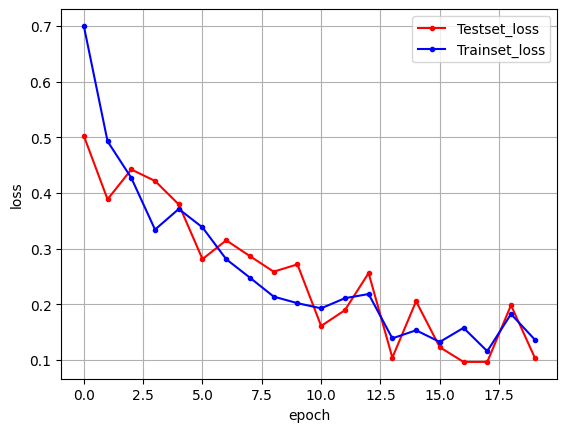

In [3]:
from IPython.core.display import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Input, models, layers, optimizers, metrics
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt

# 깃허브에 준비된 데이터를 가져온다.
!git clone https://github.com/taehojo/data-ch20.git

# 학습셋의 변형을 설정하는 부분이다.
train_datagen = ImageDataGenerator(rescale=1./255,
                                   horizontal_flip=True,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   )

train_generator = train_datagen.flow_from_directory(
    './data-ch20/train',
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary')

# 테스트셋의 정규화를 설정한다.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    './data-ch20/test',
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary')

# VGG16 모델을 불러온다.
transfer_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
transfer_model.trainable = False

# 우리의 모델에 설정한다.
finetune_model = models.Sequential()
finetune_model.add(transfer_model)
finetune_model.add(Flatten())
finetune_model.add(Dense(64))
finetune_model.add(Activation('relu'))
finetune_model.add(Dropout(0.5))
finetune_model.add(Dense(1))
finetune_model.add(Activation('sigmoid'))
finetune_model.summary()

# 모델의 실행 옵션을 설정한다.
finetune_model.compile(loss='binary_crossentropy',
                       optimizer=optimizers.Adam(learning_rate=0.0002), metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행한다.
history = finetune_model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    validation_steps=10,
    callbacks=[early_stopping_callback])

# 검즘셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 본다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

전이 학습을 사용하지 않았던 이전보다 더 높은 정확도로 출발하는 것을 볼 수 있고, 학습 속도도 빨라진 것이 확인된다. 또 그래프의 변화 추이가 안정적임을 확인할 수 있다.